# 📊 Notebook 02 — Exploratory Data Analysis (EDA)

**Purpose:** Visually explore the cleaned Kickstarter dataset to understand the
distributions, relationships, and patterns that will guide feature engineering and
modelling decisions.

**All figures saved to `../outputs/figures/` at 150 dpi.**

**Color convention throughout:**
- Blue `#3B82F6` = success / positive class
- Red `#EF4444` = failure / negative class


## Setup — Imports and Load Data

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")

OUTPUTS_PATH = "../outputs"
FIGURES_PATH = os.path.join(OUTPUTS_PATH, "figures")
os.makedirs(FIGURES_PATH, exist_ok=True)

SUCCESS_COLOR = "#3B82F6"
FAILURE_COLOR = "#EF4444"
PALETTE = {1: SUCCESS_COLOR, 0: FAILURE_COLOR}

plt.rcParams.update({
    "figure.dpi": 100,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
})

df = pd.read_parquet(os.path.join(OUTPUTS_PATH, "clean_df.parquet"))
df["launched_at"] = pd.to_numeric(df["launched_at"], errors="coerce")
df["deadline"]    = pd.to_numeric(df["deadline"], errors="coerce")
df["created_at"]  = pd.to_numeric(df.get("created_at", pd.Series(dtype=float)), errors="coerce")
df["goal"]        = pd.to_numeric(df["goal"], errors="coerce")
df["launched_dt"] = pd.to_datetime(df["launched_at"], unit="s", utc=True)

print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"Success rate: {df['success'].mean()*100:.1f}%")
print(f"Date range: {df['launched_dt'].min().strftime('%Y-%m')} → {df['launched_dt'].max().strftime('%Y-%m')}")


Loaded: 188,429 rows × 21 cols
Success rate: 62.4%
Date range: 2009-04 → 2026-02


## Section 1 — Target Variable Distribution

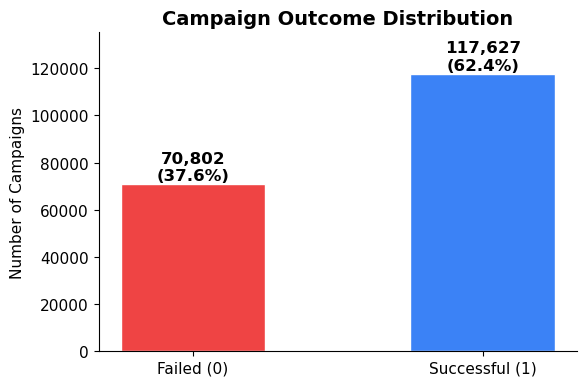

Figure saved: 01_target_distribution.png


In [2]:
fig, ax = plt.subplots(figsize=(6, 4))
vc = df["success"].value_counts().sort_index()
labels = ["Failed (0)", "Successful (1)"]
colors = [FAILURE_COLOR, SUCCESS_COLOR]
bars = ax.bar(labels, vc.values, color=colors, edgecolor="white", width=0.5)
for bar, val in zip(bars, vc.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f"{val:,}\n({val/len(df)*100:.1f}%)",
            ha="center", va="bottom", fontweight="bold", fontsize=12)
ax.set_title("Campaign Outcome Distribution", fontsize=14, fontweight="bold")
ax.set_ylabel("Number of Campaigns")
ax.set_ylim(0, vc.max() * 1.15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_PATH, "01_target_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved: 01_target_distribution.png")


## Section 2 — Temporal Patterns

We look at campaign volume and success rate over time.  
**Key question:** Is there distributional shift? A model trained on 2014 data may not
generalise well to 2024 campaigns if platform dynamics have changed.


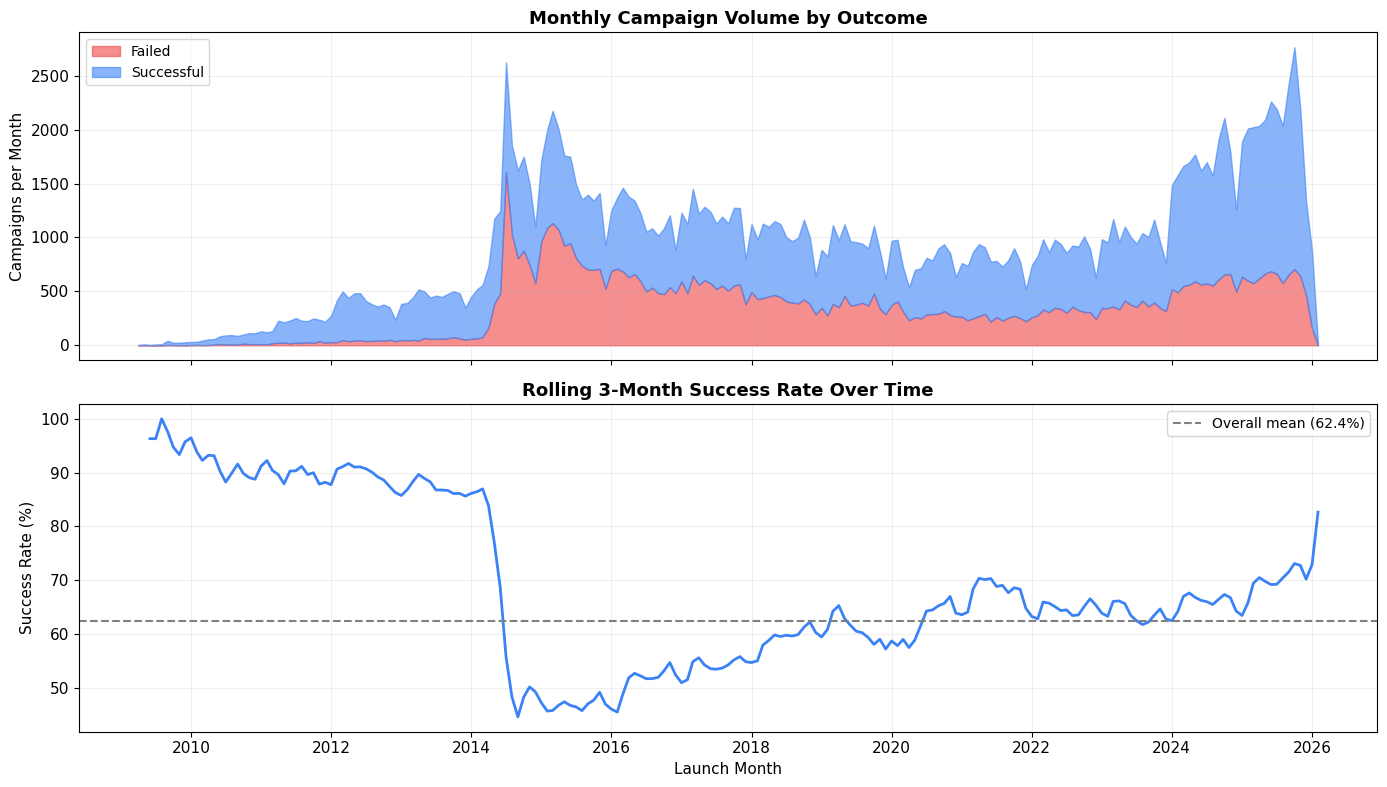

Success rate 2012-2015: 61.1%
Success rate 2022+    : 67.3%
Drift of 6.2 percentage points — distributional shift exists.


In [3]:
df["year_month"] = df["launched_dt"].dt.to_period("M")
monthly = df.groupby(["year_month", "success"]).size().unstack(fill_value=0)
monthly.index = monthly.index.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Campaign volume
axes[0].fill_between(monthly.index, monthly.get(0, 0), alpha=0.6,
                     color=FAILURE_COLOR, label="Failed")
axes[0].fill_between(monthly.index, monthly.get(0, 0),
                     monthly.get(0, 0) + monthly.get(1, 0),
                     alpha=0.6, color=SUCCESS_COLOR, label="Successful")
axes[0].set_title("Monthly Campaign Volume by Outcome", fontweight="bold")
axes[0].set_ylabel("Campaigns per Month")
axes[0].legend()
axes[0].grid(alpha=0.2)

# Success rate over time
monthly_total = monthly.sum(axis=1)
monthly_rate  = (monthly.get(1, pd.Series(0, index=monthly.index)) / monthly_total).rolling(3).mean()
axes[1].plot(monthly.index, monthly_rate * 100, color=SUCCESS_COLOR, lw=2)
axes[1].axhline(df["success"].mean() * 100, color="grey", linestyle="--",
                label=f"Overall mean ({df['success'].mean()*100:.1f}%)")
axes[1].set_title("Rolling 3-Month Success Rate Over Time", fontweight="bold")
axes[1].set_ylabel("Success Rate (%)")
axes[1].set_xlabel("Launch Month")
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_PATH, "02_temporal_patterns.png"), dpi=150, bbox_inches="tight")
plt.show()

# Distributional shift comment
rate_early = df[df["launched_dt"].dt.year <= 2015]["success"].mean()
rate_late  = df[df["launched_dt"].dt.year >= 2022]["success"].mean()
print(f"Success rate 2012-2015: {rate_early*100:.1f}%")
print(f"Success rate 2022+    : {rate_late*100:.1f}%")
print(f"Drift of {abs(rate_late - rate_early)*100:.1f} percentage points — distributional shift exists.")


## Section 3 — Goal Amount Analysis

Campaign goal is the amount the creator needs to raise. It has extreme right skew
(some campaigns ask for millions). We analyse it on a log scale.

**Key finding:** Failed campaigns set goals approximately 2–3x higher than successful ones.


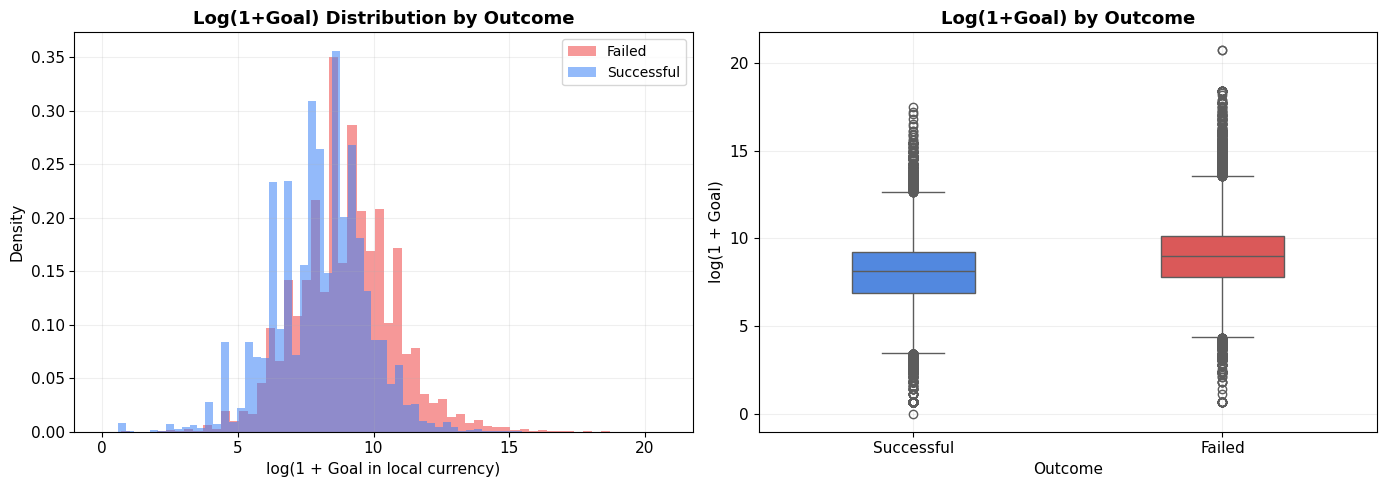

Median goal — Successful : $     3,500
Median goal — Failed     : $     8,000
Ratio (Failed/Successful): 2.29x


In [4]:
df["log_goal"] = np.log1p(df["goal"].clip(lower=0))
success_goals  = df[df["success"] == 1]["log_goal"].dropna()
failure_goals  = df[df["success"] == 0]["log_goal"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(failure_goals, bins=60, alpha=0.55, color=FAILURE_COLOR,
             label="Failed", density=True)
axes[0].hist(success_goals, bins=60, alpha=0.55, color=SUCCESS_COLOR,
             label="Successful", density=True)
axes[0].set_title("Log(1+Goal) Distribution by Outcome", fontweight="bold")
axes[0].set_xlabel("log(1 + Goal in local currency)")
axes[0].set_ylabel("Density")
axes[0].legend()
axes[0].grid(alpha=0.2)

# Box plot
plot_data = df[["log_goal", "success"]].dropna()
plot_data["Outcome"] = plot_data["success"].map({1: "Successful", 0: "Failed"})
sns.boxplot(data=plot_data, x="Outcome", y="log_goal",
            palette={"Successful": SUCCESS_COLOR, "Failed": FAILURE_COLOR},
            ax=axes[1], width=0.4)
axes[1].set_title("Log(1+Goal) by Outcome", fontweight="bold")
axes[1].set_ylabel("log(1 + Goal)")
axes[1].grid(alpha=0.2)

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_PATH, "03_goal_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

med_success = np.expm1(success_goals.median())
med_failure = np.expm1(failure_goals.median())
print(f"Median goal — Successful : ${med_success:>10,.0f}")
print(f"Median goal — Failed     : ${med_failure:>10,.0f}")
print(f"Ratio (Failed/Successful): {med_failure/med_success:.2f}x")


## Section 4 — Category Analysis

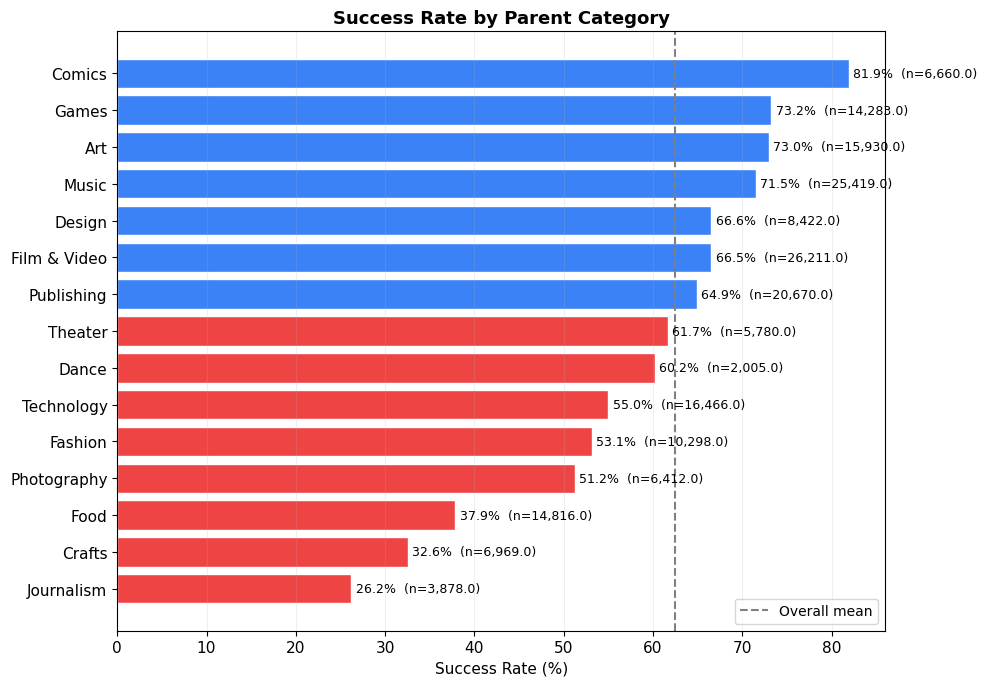

In [5]:
# Success rate by parent category
cat_stats = (df.groupby("cat_parent_name")["success"]
               .agg(["sum", "count", "mean"])
               .rename(columns={"sum": "n_success", "count": "n_total", "mean": "success_rate"})
               .dropna()
               .sort_values("success_rate", ascending=True))

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(cat_stats.index, cat_stats["success_rate"] * 100,
               color=[SUCCESS_COLOR if r > df["success"].mean() else FAILURE_COLOR
                      for r in cat_stats["success_rate"]], edgecolor="white")
for bar, (_, row) in zip(bars, cat_stats.iterrows()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{row['success_rate']*100:.1f}%  (n={row['n_total']:,})",
            va="center", fontsize=9)
ax.axvline(df["success"].mean() * 100, color="grey", linestyle="--", label="Overall mean")
ax.set_title("Success Rate by Parent Category", fontweight="bold")
ax.set_xlabel("Success Rate (%)")
ax.legend()
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_PATH, "04_category_success_rate.png"), dpi=150, bbox_inches="tight")
plt.show()


## Section 5 — Staff Pick Analysis

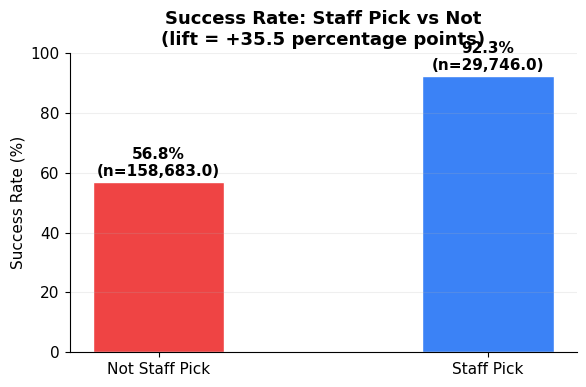

Staff pick success rate : 92.3%
Non-staff pick rate     : 56.8%
Lift                    : +35.5 percentage points


In [6]:
sp = df["staff_pick"].map({"True": 1, "False": 0, True: 1, False: 0}).fillna(0).astype(int)
df["staff_pick_int"] = sp
sp_stats = df.groupby("staff_pick_int")["success"].agg(["sum","count","mean"])
sp_stats.index = ["Not Staff Pick", "Staff Pick"]

rate_sp    = sp_stats.loc["Staff Pick", "mean"]
rate_nonsp = sp_stats.loc["Not Staff Pick", "mean"]
lift       = (rate_sp - rate_nonsp) * 100

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(sp_stats.index, sp_stats["mean"] * 100,
              color=[FAILURE_COLOR, SUCCESS_COLOR], edgecolor="white", width=0.4)
for bar, (idx, row) in zip(bars, sp_stats.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{row['mean']*100:.1f}%\n(n={row['count']:,})",
            ha="center", va="bottom", fontweight="bold")
ax.set_title(f"Success Rate: Staff Pick vs Not\n(lift = +{lift:.1f} percentage points)", fontweight="bold")
ax.set_ylabel("Success Rate (%)")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_PATH, "05_staff_pick.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Staff pick success rate : {rate_sp*100:.1f}%")
print(f"Non-staff pick rate     : {rate_nonsp*100:.1f}%")
print(f"Lift                    : +{lift:.1f} percentage points")


## Section 6 — Summary

In [7]:
print("Notebook 02 (EDA) complete.")
print(f"Figures saved to: {os.path.abspath(FIGURES_PATH)}")


Notebook 02 (EDA) complete.
Figures saved to: /Users/dacobri/Desktop/MSc Business Analytics/Classes Term 2/Artificial Intelligence 2/Final Project/Kickstarter_ML_Project/outputs/figures
